In [ ]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time, warnings, os, json, gc, random
from itertools import product
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.models as tv_models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from codecarbon import EmissionsTracker

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch   : {torch.__version__}")
print(f"Device    : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")
    print(f"Compute   : {torch.cuda.get_device_capability(0)}")
print('✅ Imports done')

PyTorch   : 2.11.0+cu128
Device    : cuda
GPU       : NVIDIA GeForce RTX 5090
VRAM      : 34 GB
Compute   : (12, 0)
✅ Imports done


In [ ]:
# ── 2. CONFIG ─────────────────────────────────────────────────────────────────
IMG_SIZE    = 128
NUM_CLASSES = 10
BATCH_SIZE  = 512
EPOCHS      = 30
PATIENCE    = 5
OUTPUT_DIR  = './cifar10_output'
DATA_DIR    = './cifar10_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR,   exist_ok=True)

CLASS_NAMES   = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
MODELS_LIST   = ['EfficientNetB0', 'ResNet50', 'MobileNetV2']

PARAM_GRID = {
    'learning_rate': [1e-3, 1e-4],
    'dropout_rate':  [0.2, 0.4],
    'dense_units':   [64, 128, 256],
    'optimizer':     ['adam', 'sgd'],
}
grid_combinations = [
    {'learning_rate': lr, 'dropout_rate': dr, 'dense_units': du, 'optimizer': opt}
    for lr, dr, du, opt in product(
        PARAM_GRID['learning_rate'], PARAM_GRID['dropout_rate'],
        PARAM_GRID['dense_units'],   PARAM_GRID['optimizer'],
    )
]
# ── True Random Search: sample from wider continuous-ish distributions
N_RANDOM_TRIALS = 12

def sample_random_params(n, seed=42):
    """Sample hyperparams independently — this is what makes it Random Search.
    Uses the same axes as the grid but adds finer-grained values so the
    two methods genuinely explore different points in the space."""
    rng = random.Random(seed)
    lr_pool    = [1e-3, 5e-4, 2e-4, 1e-4]          # wider than grid
    drop_pool  = [round(x * 0.05, 2)
                  for x in range(2, 11)]             # 0.10 … 0.50 in 0.05 steps
    units_pool = [64, 96, 128, 192, 256]             # includes mid-points
    opt_pool   = ['adam', 'sgd']
    return [
        {
            'learning_rate': rng.choice(lr_pool),
            'dropout_rate':  rng.choice(drop_pool),
            'dense_units':   rng.choice(units_pool),
            'optimizer':     rng.choice(opt_pool),
        }
        for _ in range(n)
    ]

random_combinations = sample_random_params(N_RANDOM_TRIALS)

print(f"Grid trials per model   : {len(grid_combinations)}")
print(f"Random trials per model : {len(random_combinations)}")
print(f"Total runs              : {len(grid_combinations) * len(MODELS_LIST) + len(random_combinations) * len(MODELS_LIST)}")
print(f"Random params sampled   :")
for i, p in enumerate(random_combinations, 1):
    print(f"  {i:02d}: {p}")
print('✅ Config done')

Grid trials per model   : 24
Random trials per model : 12
Total runs              : 108
Random params sampled   :
  01: {'learning_rate': 0.001, 'dropout_rate': 0.1, 'dense_units': 128, 'optimizer': 'adam'}
  02: {'learning_rate': 0.0005, 'dropout_rate': 0.2, 'dense_units': 64, 'optimizer': 'adam'}
  03: {'learning_rate': 0.0001, 'dropout_rate': 0.1, 'dense_units': 64, 'optimizer': 'adam'}
  04: {'learning_rate': 0.0005, 'dropout_rate': 0.25, 'dense_units': 256, 'optimizer': 'adam'}
  05: {'learning_rate': 0.0005, 'dropout_rate': 0.5, 'dense_units': 192, 'optimizer': 'adam'}
  06: {'learning_rate': 0.0001, 'dropout_rate': 0.3, 'dense_units': 64, 'optimizer': 'adam'}
  07: {'learning_rate': 0.0001, 'dropout_rate': 0.35, 'dense_units': 128, 'optimizer': 'adam'}
  08: {'learning_rate': 0.0005, 'dropout_rate': 0.35, 'dense_units': 64, 'optimizer': 'adam'}
  09: {'learning_rate': 0.0001, 'dropout_rate': 0.15, 'dense_units': 128, 'optimizer': 'sgd'}
  10: {'learning_rate': 0.0002, 'dropout_r

In [ ]:
# ── 3. LOAD & CACHE DATA TO GPU (float16 to save VRAM)


def cache_to_gpu(dataset, size=IMG_SIZE, batch_size=1024, label=''):
    """Resize, normalise and store entire dataset in GPU VRAM as float16."""
    mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1, 3, 1, 1)
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=0,
                        shuffle=False, pin_memory=(DEVICE.type == 'cuda'))
    all_imgs, all_labels = [], []
    t0 = time.time()
    print(f"  Caching {label} ({len(dataset)} images) → GPU ...", end=' ', flush=True)
    for imgs, lbls in loader:
        imgs = F.interpolate(imgs.to(DEVICE), size=(size, size),
                             mode='bilinear', align_corners=False)
        imgs = ((imgs - mean) / std).half()   # float16 — half the VRAM
        all_imgs.append(imgs)
        all_labels.append(lbls.to(DEVICE))
    imgs_gpu   = torch.cat(all_imgs)
    labels_gpu = torch.cat(all_labels)
    mb = imgs_gpu.element_size() * imgs_gpu.nelement() / 1e6
    print(f"done in {time.time()-t0:.1f}s  ({mb:.0f} MB)")
    return imgs_gpu, labels_gpu

# Download raw datasets (ToTensor only — GPU handles resize + normalise)
raw_train_full = CIFAR10(root=DATA_DIR, train=True,  download=True,
                         transform=transforms.ToTensor())
raw_test_full  = CIFAR10(root=DATA_DIR, train=False, download=True,
                         transform=transforms.ToTensor())

# Stratified 80/20 split
targets = np.array(raw_train_full.targets)
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42
)

# Cache everything — clear any leftover VRAM first
torch.cuda.empty_cache(); gc.collect()
print(f"VRAM before cache : {torch.cuda.memory_allocated()/1e9:.1f} GB")
print("=== Caching datasets to GPU VRAM ===")
all_imgs_gpu,  all_labels_gpu  = cache_to_gpu(raw_train_full, label='train+val')
test_imgs_gpu, test_labels_gpu = cache_to_gpu(raw_test_full,  label='test')

train_imgs_gpu   = all_imgs_gpu[train_idx]
train_labels_gpu = all_labels_gpu[train_idx]
val_imgs_gpu     = all_imgs_gpu[val_idx]
val_labels_gpu   = all_labels_gpu[val_idx]

vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\nTrain  : {train_imgs_gpu.shape}  dtype={train_imgs_gpu.dtype}")
print(f"Val    : {val_imgs_gpu.shape}")
print(f"Test   : {test_imgs_gpu.shape}")
print(f"VRAM   : {vram_used:.1f} / {vram_total:.0f} GB")
assert train_imgs_gpu.device.type == 'cuda', 'ERROR: data is not on GPU!'
print('✅ Data cached on GPU')

VRAM before cache : 0.0 GB
=== Caching datasets to GPU VRAM ===
  Caching train+val (50000 images) → GPU ... done in 2.7s  (4915 MB)
  Caching test (10000 images) → GPU ... done in 0.6s  (983 MB)

Train  : torch.Size([40000, 3, 128, 128])  dtype=torch.float16
Val    : torch.Size([10000, 3, 128, 128])
Test   : torch.Size([10000, 3, 128, 128])
VRAM   : 10.8 / 34 GB
✅ Data cached on GPU


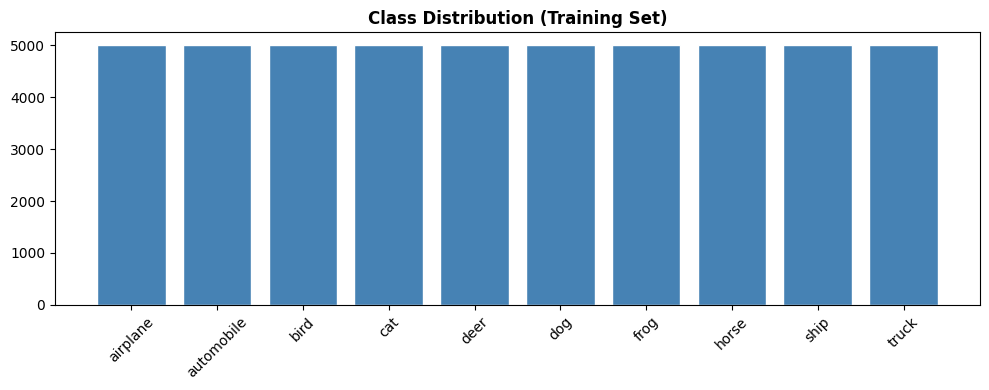

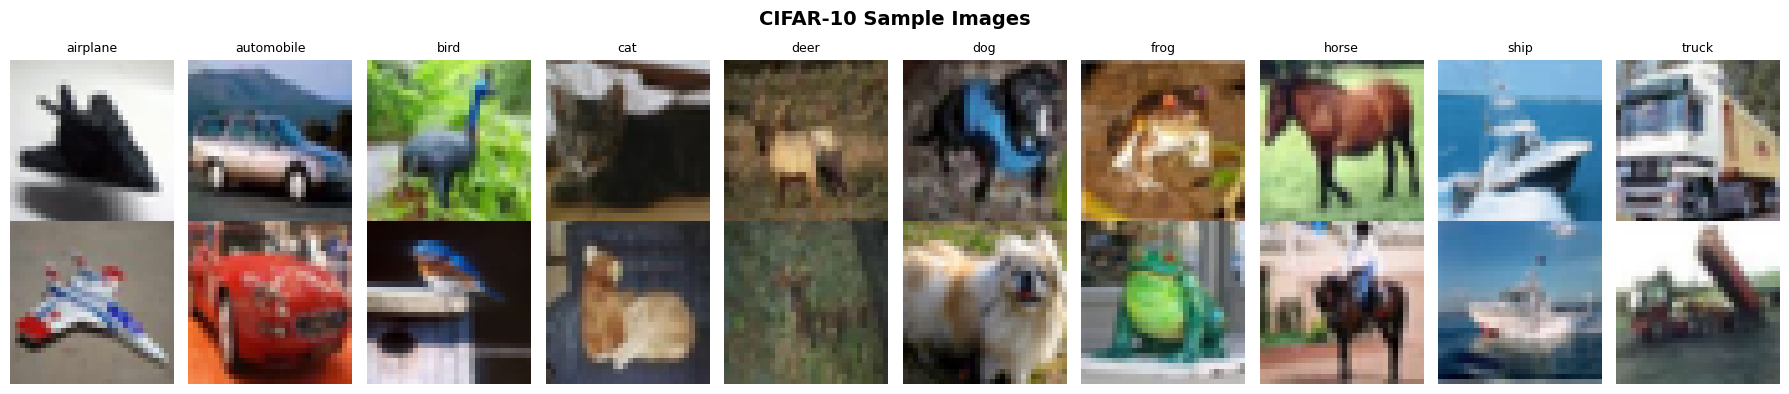

In [ ]:
# ── 4. VISUALIZE DATA ─────────────────────────────────────────────────────────
unique, counts = np.unique(targets, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
plt.xticks(rotation=45)
plt.title('Class Distribution (Training Set)', fontweight='bold')
plt.tight_layout(); plt.show()

# Sample images
raw_vis = CIFAR10(root=DATA_DIR, train=True, download=False,
                  transform=transforms.ToTensor())
raw_targets = np.array(raw_vis.targets)
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
for cls_idx in range(10):
    idxs = np.where(raw_targets == cls_idx)[0]
    for row, sample_idx in enumerate(idxs[:2]):
        img, _ = raw_vis[sample_idx]
        axes[row, cls_idx].imshow(img.permute(1, 2, 0).numpy())
        if row == 0:
            axes[row, cls_idx].set_title(CLASS_NAMES[cls_idx], fontsize=9)
        axes[row, cls_idx].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ── 5. MODEL BUILDER ──────────────────────────────────────────────────────────
def build_model(model_name: str, dropout_rate: float = 0.3,
                dense_units: int = 128) -> nn.Module:
    """Pretrained backbone with custom head. Full network is trainable."""
    if model_name == 'EfficientNetB0':
        base = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = base.classifier[1].in_features
        base.classifier = nn.Sequential(
            nn.Linear(in_features, dense_units), nn.ReLU(),
            nn.BatchNorm1d(dense_units), nn.Dropout(dropout_rate),
            nn.Linear(dense_units, NUM_CLASSES),
        )
    elif model_name == 'ResNet50':
        base = tv_models.resnet50(
            weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = base.fc.in_features
        base.fc = nn.Sequential(
            nn.Linear(in_features, dense_units), nn.ReLU(),
            nn.BatchNorm1d(dense_units), nn.Dropout(dropout_rate),
            nn.Linear(dense_units, NUM_CLASSES),
        )
    elif model_name == 'MobileNetV2':
        base = tv_models.mobilenet_v2(
            weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = base.classifier[1].in_features
        base.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, dense_units), nn.ReLU(),
            nn.BatchNorm1d(dense_units), nn.Dropout(dropout_rate),
            nn.Linear(dense_units, NUM_CLASSES),
        )
    else:
        raise ValueError(f'Unknown model: {model_name}')

    # All parameters trainable
    for param in base.parameters():
        param.requires_grad = True

    return base

# Sanity check
for mn in MODELS_LIST:
    m = build_model(mn)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f'✅ {mn:15s} trainable: {trainable:>10,} / {total:>10,}')
    del m
torch.cuda.empty_cache()

✅ EfficientNetB0  trainable:  4,173,062 /  4,173,062
✅ ResNet50        trainable: 23,771,850 / 23,771,850
✅ MobileNetV2     trainable:  2,389,386 /  2,389,386


In [ ]:
# ── 6. TRAINING FUNCTIONS (GPU tensor — no DataLoader overhead) ─────────────────────

def train_one_epoch_cached(model, imgs, labels, criterion, optimizer, scaler,
                            batch_size=BATCH_SIZE):
    model.train()
    perm   = torch.randperm(len(imgs), device=DEVICE)
    imgs   = imgs[perm]
    labels = labels[perm]
    running_loss, correct, total = 0.0, 0, 0
    for start in range(0, len(imgs), batch_size):
        x = imgs[start : start + batch_size]
        y = labels[start : start + batch_size]
        mask = torch.rand(x.size(0), device=DEVICE) > 0.5
        x = torch.where(mask.view(-1, 1, 1, 1), torch.flip(x, dims=[3]), x)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out  = model(x.float())
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * x.size(0)
        correct      += out.argmax(1).eq(y).sum().item()
        total        += y.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_cached(model, imgs, labels, criterion, batch_size=BATCH_SIZE):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for start in range(0, len(imgs), batch_size):
        x = imgs[start : start + batch_size]
        y = labels[start : start + batch_size]
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out  = model(x.float())
            loss = criterion(out, y)
        running_loss += loss.item() * x.size(0)
        correct      += out.argmax(1).eq(y).sum().item()
        total        += y.size(0)
    return running_loss / total, correct / total


def train_and_evaluate(model_name, params, epochs=EPOCHS):
    gc.collect()
    torch.cuda.empty_cache()
    model = build_model(model_name, dropout_rate=params["dropout_rate"],
                        dense_units=params["dense_units"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    if params["optimizer"] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"])
    else:
        optimizer = optim.SGD(model.parameters(), lr=params["learning_rate"],
                              momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6)
    scaler = torch.amp.GradScaler(enabled=DEVICE.type == "cuda")
    best_val_acc, best_epoch, patience_count, best_state = 0.0, 0, 0, None
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch_cached(model, train_imgs_gpu, train_labels_gpu,
                                                  criterion, optimizer, scaler)
        val_loss, val_acc = evaluate_cached(model, val_imgs_gpu, val_labels_gpu, criterion)
        scheduler.step(val_acc)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_epoch     = epoch
            patience_count = 0
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break
    if best_state:
        model.load_state_dict(best_state)
    del model
    torch.cuda.empty_cache()
    return best_val_acc, time.time() - t0, epoch, best_epoch, history, best_state


print('Running speed benchmark (1 epoch)...')
_m   = build_model('EfficientNetB0').to(DEVICE)
_cr  = nn.CrossEntropyLoss()
_opt = optim.Adam(_m.parameters(), lr=1e-3)
_sc  = torch.amp.GradScaler(enabled=True)
torch.cuda.synchronize()
_t0  = time.time()
train_one_epoch_cached(_m, train_imgs_gpu, train_labels_gpu, _cr, _opt, _sc)
torch.cuda.synchronize()
_ep  = time.time() - _t0
del _m; torch.cuda.empty_cache()
print(f'  1 epoch        : {_ep:.1f}s')
print(f'  30 epochs      : {_ep*30/60:.1f} min')
print('✅ Training functions ready')


Running speed benchmark (1 epoch)...
  1 epoch        : 14.5s
  30 epochs      : 7.3 min
✅ Training functions ready


In [ ]:
# ── 7. SEARCH RUNNER ────────────────────────────────────────────
def run_search(method, model_name, param_list):
    SEP = "=" * 60
    print(f"\n{SEP}")
    print(f"  {method} | {model_name}  ({len(param_list)} trials)")
    print(SEP)
    emissions_dir = os.path.join(OUTPUT_DIR, "emissions")
    os.makedirs(emissions_dir, exist_ok=True)
    trial_results, cumulative_g = [], 0.0
    overall_t0 = time.time()
    TDP_WATTS  = 575
    best_history = None
    _best_state_ref = None
    for i, params in enumerate(param_list):
        print(f"  Trial {i+1:02d}/{len(param_list)} {params}", end=" ", flush=True)
        trial_t0 = time.time()
        val_acc, dur, epochs_trained, best_epoch, history, trial_best_state = train_and_evaluate(model_name, params)
        trial_duration = time.time() - trial_t0
        trial_kwh = (TDP_WATTS * trial_duration) / (1000 * 3600)
        trial_g   = trial_kwh * 233
        cumulative_g += trial_g
        trial_results.append({
            "params":                 params,
            "val_accuracy":           val_acc,
            "duration":               dur,
            "epochs_trained":         epochs_trained,
            "best_epoch":             best_epoch,
            "trial_emissions_g":      trial_g,
            "cumulative_emissions_g": cumulative_g,
        })
        print(f"→ val_acc={val_acc:.4f}  ({dur:.1f}s)  [{trial_g:.4f} g CO₂]")
        best_idx_so_far = max(range(len(trial_results)),
                              key=lambda k: trial_results[k]["val_accuracy"])
        if best_idx_so_far == len(trial_results) - 1:
            best_history = history
            _best_state_ref = trial_best_state
    total_duration = time.time() - overall_t0
    best_idx = max(range(len(trial_results)),
                   key=lambda k: trial_results[k]["val_accuracy"])
    best = trial_results[best_idx]
    result = {
        "method":                     method,
        "model":                      model_name,
        "n_trials":                   len(param_list),
        "best_params":                best["params"],
        "best_val_acc":               best["val_accuracy"],
        "best_trial":                 best_idx + 1,
        "total_time_s":               total_duration,
        "initial_val_acc":            trial_results[0]["val_accuracy"],
        "initial_params_emissions_g": trial_results[0]["trial_emissions_g"],
        "to_best_emissions_g":        trial_results[best_idx]["cumulative_emissions_g"],
        "total_emissions_g":          cumulative_g,
        "energy_kwh":                 round(cumulative_g / (1000 * 0.233), 6),
        "all_trials":                 trial_results,
        "best_trial_history":         best_history,
        "best_state":                 _best_state_ref,
    }
    best_val_acc = result["best_val_acc"]
    best_trial   = result["best_trial"]
    print(f"\n  ✅ Best val_acc : {best_val_acc:.4f}  (Trial #{best_trial})")
    print(f"  ⏱  Total time  : {total_duration/60:.1f} min")
    print(f"  🌿 CO₂ total   : {cumulative_g:.3f} g")
    return result

print("✅ run_search ready")


✅ run_search ready


In [ ]:
# ── 8. RUN ALL EXPERIMENTS ────────────────────────────────────────────────────
all_results = []

for model_name in MODELS_LIST:
    res_grid = run_search('GridSearch',   model_name, grid_combinations)
    all_results.append(res_grid)

    res_rand = run_search('RandomSearch', model_name, random_combinations)
    all_results.append(res_rand)

print('\n✅ All experiments complete!')


  GridSearch | EfficientNetB0  (24 trials)
  Trial 01/24 {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 64, 'optimizer': 'adam'} → val_acc=0.9613  (144.0s)  [5.3659 g CO₂]
  Trial 02/24 {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 64, 'optimizer': 'sgd'} → val_acc=0.9310  (176.4s)  [6.5730 g CO₂]
  Trial 03/24 {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 128, 'optimizer': 'adam'} → val_acc=0.9605  (106.9s)  [3.9858 g CO₂]
  Trial 04/24 {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 128, 'optimizer': 'sgd'} → val_acc=0.9311  (175.5s)  [6.5408 g CO₂]
  Trial 05/24 {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 256, 'optimizer': 'adam'} → val_acc=0.9637  (177.1s)  [6.5984 g CO₂]
  Trial 06/24 {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 256, 'optimizer': 'sgd'} → val_acc=0.9296  (175.9s)  [6.5539 g CO₂]
  Trial 07/24 {'learning_rate': 0.001, 'dropout_rate': 0.4, 'dense_units': 64, 'optimizer': 'adam

In [ ]:
# ── 9. FINAL TEST EVALUATION ──────────────────────────────────────────────────────
from sklearn.metrics import (classification_report, f1_score, precision_score,
                              recall_score, roc_auc_score, confusion_matrix)
from sklearn.preprocessing import label_binarize

test_results = []

for res in all_results:
    model_name = res["model"]
    params     = res["best_params"]
    model = build_model(model_name, dropout_rate=params["dropout_rate"],
                        dense_units=params["dense_units"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    model.load_state_dict(res["best_state"])

    test_loss, test_acc = evaluate_cached(model, test_imgs_gpu, test_labels_gpu, criterion)
    all_preds, all_labels_list, all_probs = [], [], []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(test_imgs_gpu), BATCH_SIZE):
            x = test_imgs_gpu[start : start + BATCH_SIZE]
            y = test_labels_gpu[start : start + BATCH_SIZE]
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x.float())
            probs = torch.softmax(out.float(), dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels_list.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    all_preds      = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)
    all_probs_arr  = np.array(all_probs)
    f1        = f1_score(all_labels_arr, all_preds, average="weighted")
    precision = precision_score(all_labels_arr, all_preds, average="weighted", zero_division=0)
    recall    = recall_score(all_labels_arr, all_preds, average="weighted", zero_division=0)
    y_bin     = label_binarize(all_labels_arr, classes=list(range(NUM_CLASSES)))
    roc_auc   = roc_auc_score(y_bin, all_probs_arr, average="macro", multi_class="ovr")
    print(f"\n{res['method']} | {model_name}  test_acc={test_acc:.4f}")
    print(f"  F1 (weighted)   : {f1:.4f}")
    print(f"  Precision (w.)  : {precision:.4f}")
    print(f"  Recall (w.)     : {recall:.4f}")
    print(f"  ROC-AUC (macro) : {roc_auc:.4f}")
    print(classification_report(all_labels_list, all_preds, target_names=CLASS_NAMES))
    test_results.append({
        "method":    res["method"],
        "model":     model_name,
        "test_acc":  test_acc,
        "test_loss": test_loss,
        "f1":        f1,
        "precision": precision,
        "recall":    recall,
        "roc_auc":   roc_auc,
        "preds":     all_preds,
        "labels":    all_labels_arr,
    })
    del model; torch.cuda.empty_cache()

summary_rows = []
for res, tr in zip(all_results, test_results):
    summary_rows.append({
        "Method":                     res["method"],
        "Model":                      res["model"],
        "Initial Val Acc":            round(res["initial_val_acc"],             4),
        "Best Val Acc":               round(res["best_val_acc"],                4),
        "Test Acc":                   round(tr["test_acc"],                     4),
        "F1":                         round(tr["f1"],                           4),
        "Precision":                  round(tr["precision"],                    4),
        "Recall":                     round(tr["recall"],                       4),
        "ROC-AUC":                    round(tr["roc_auc"],                      4),
        "Best Trial":                 res["best_trial"],
        "N Trials":                   res["n_trials"],
        "Avg Epochs":                 round(np.mean([t["epochs_trained"] for t in res["all_trials"]]), 1),
        "Total Time (min)":           round(res["total_time_s"] / 60,           1),
        "CO2 - Initial Params (g)":   round(res["initial_params_emissions_g"],  4),
        "CO2 - To Best Trial (g)":    round(res["to_best_emissions_g"],          4),
        "CO2 - Total All Trials (g)": round(res["total_emissions_g"],            4),
        "Energy (kWh)":               round(res["energy_kwh"],                   6),
    })
df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*80)
print("SUMMARY (with F1, Precision, Recall, ROC-AUC)")
print("="*80)
print(df_summary.to_string(index=False))



GridSearch | EfficientNetB0  test_acc=0.9602
  F1 (weighted)   : 0.9601
  Precision (w.)  : 0.9603
  Recall (w.)     : 0.9602
  ROC-AUC (macro) : 0.9962
              precision    recall  f1-score   support

    airplane       0.97      0.97      0.97      1000
  automobile       0.97      0.98      0.98      1000
        bird       0.97      0.95      0.96      1000
         cat       0.94      0.90      0.92      1000
        deer       0.95      0.97      0.96      1000
         dog       0.91      0.93      0.92      1000
        frog       0.98      0.99      0.98      1000
       horse       0.98      0.96      0.97      1000
        ship       0.97      0.98      0.97      1000
       truck       0.97      0.97      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000


RandomSearch | EfficientNetB0  test_acc=0.9573
  F1 (weighted)   : 0.9573
  Precision 

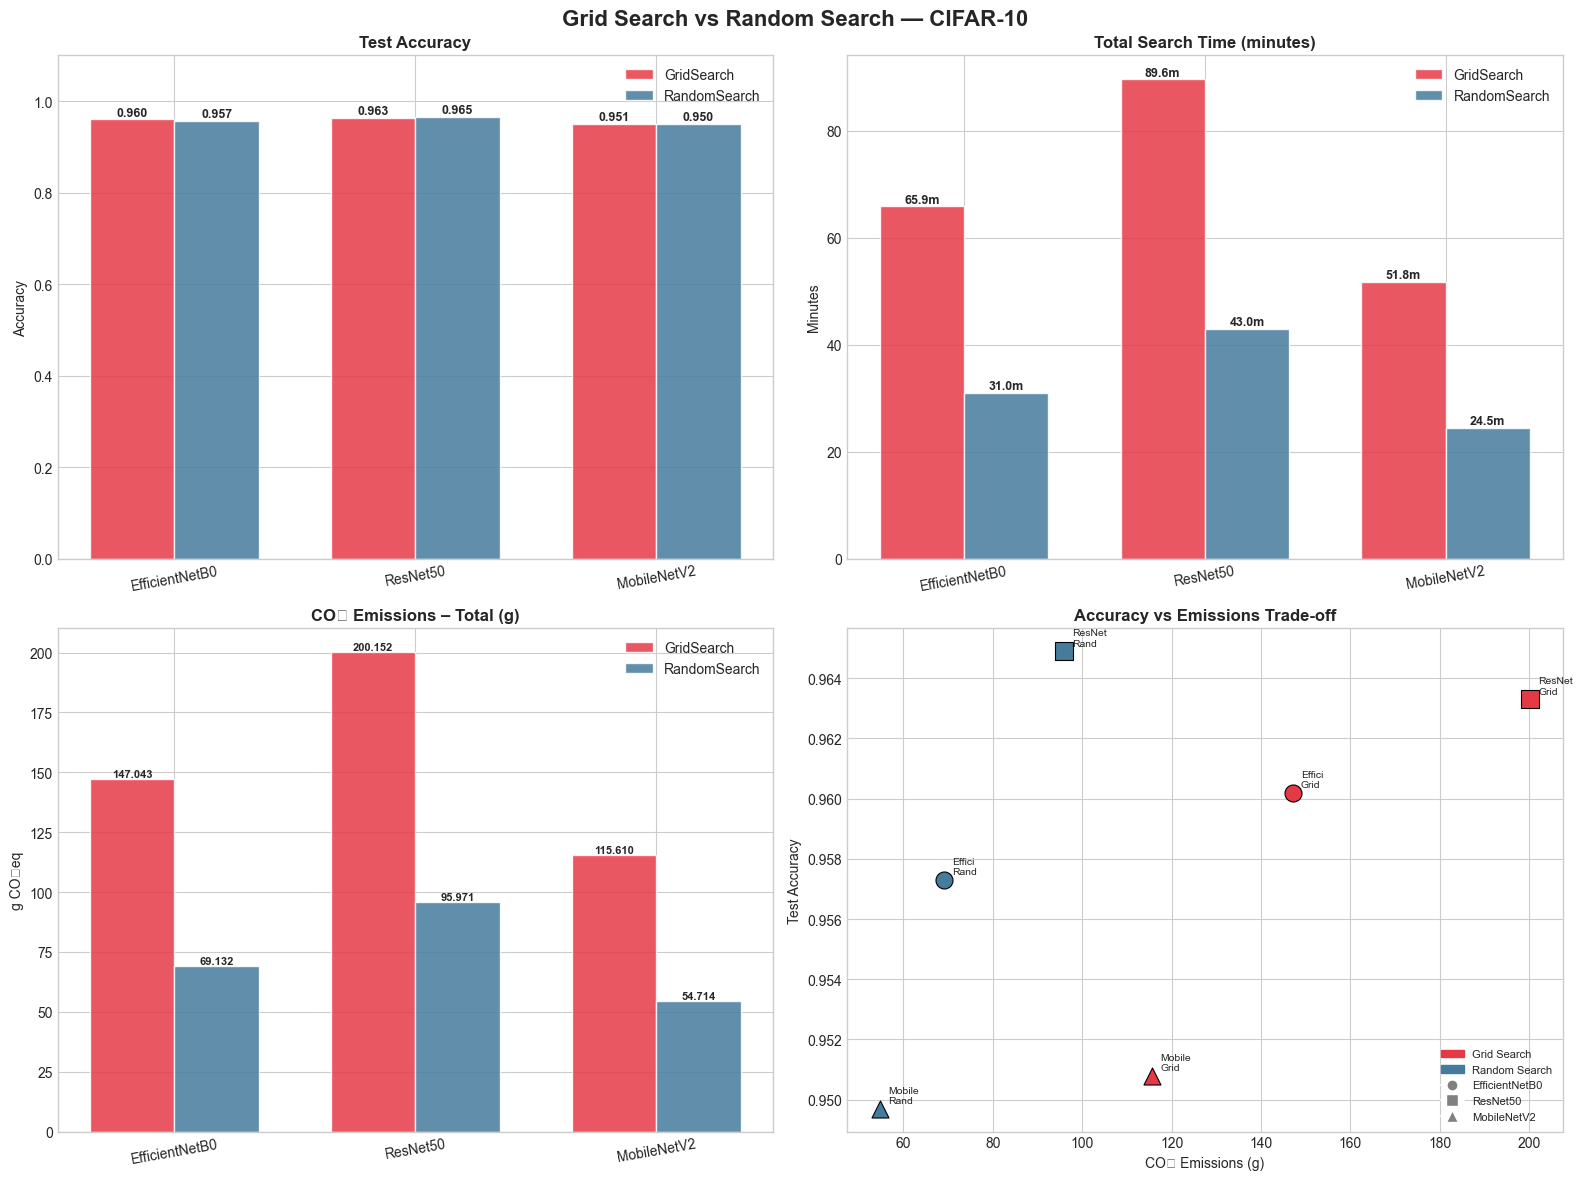

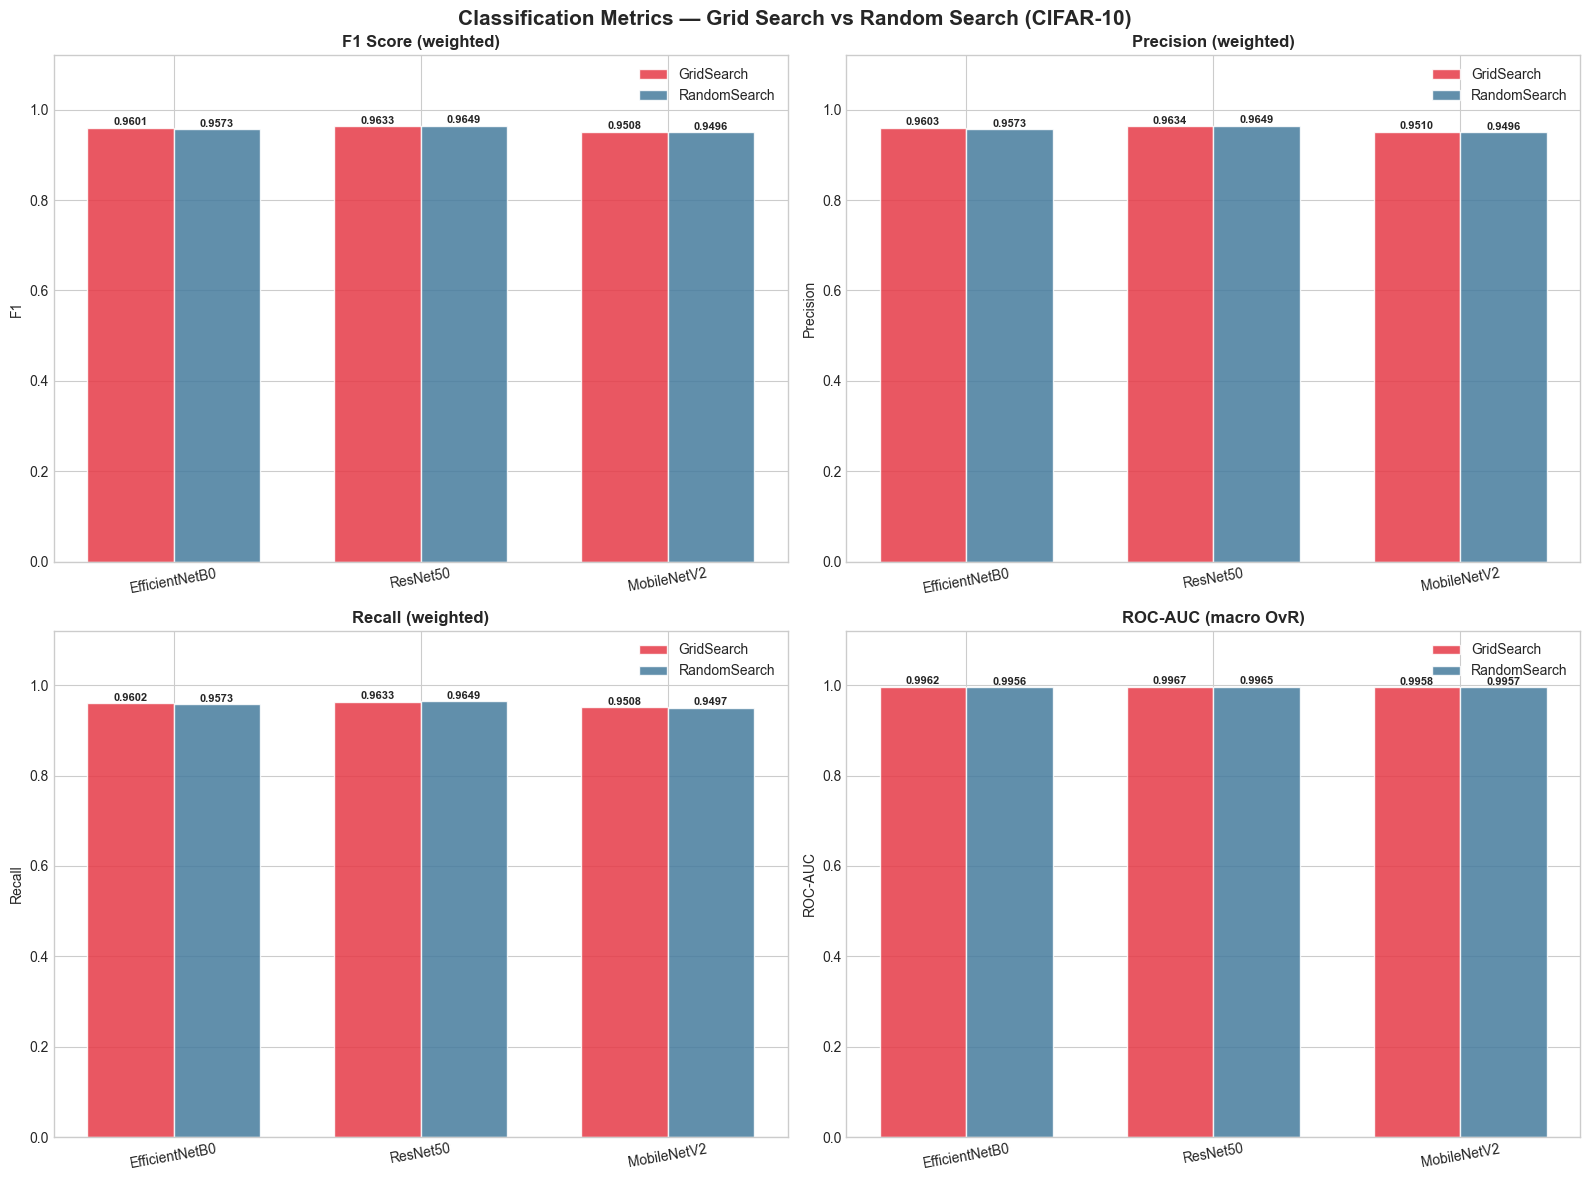

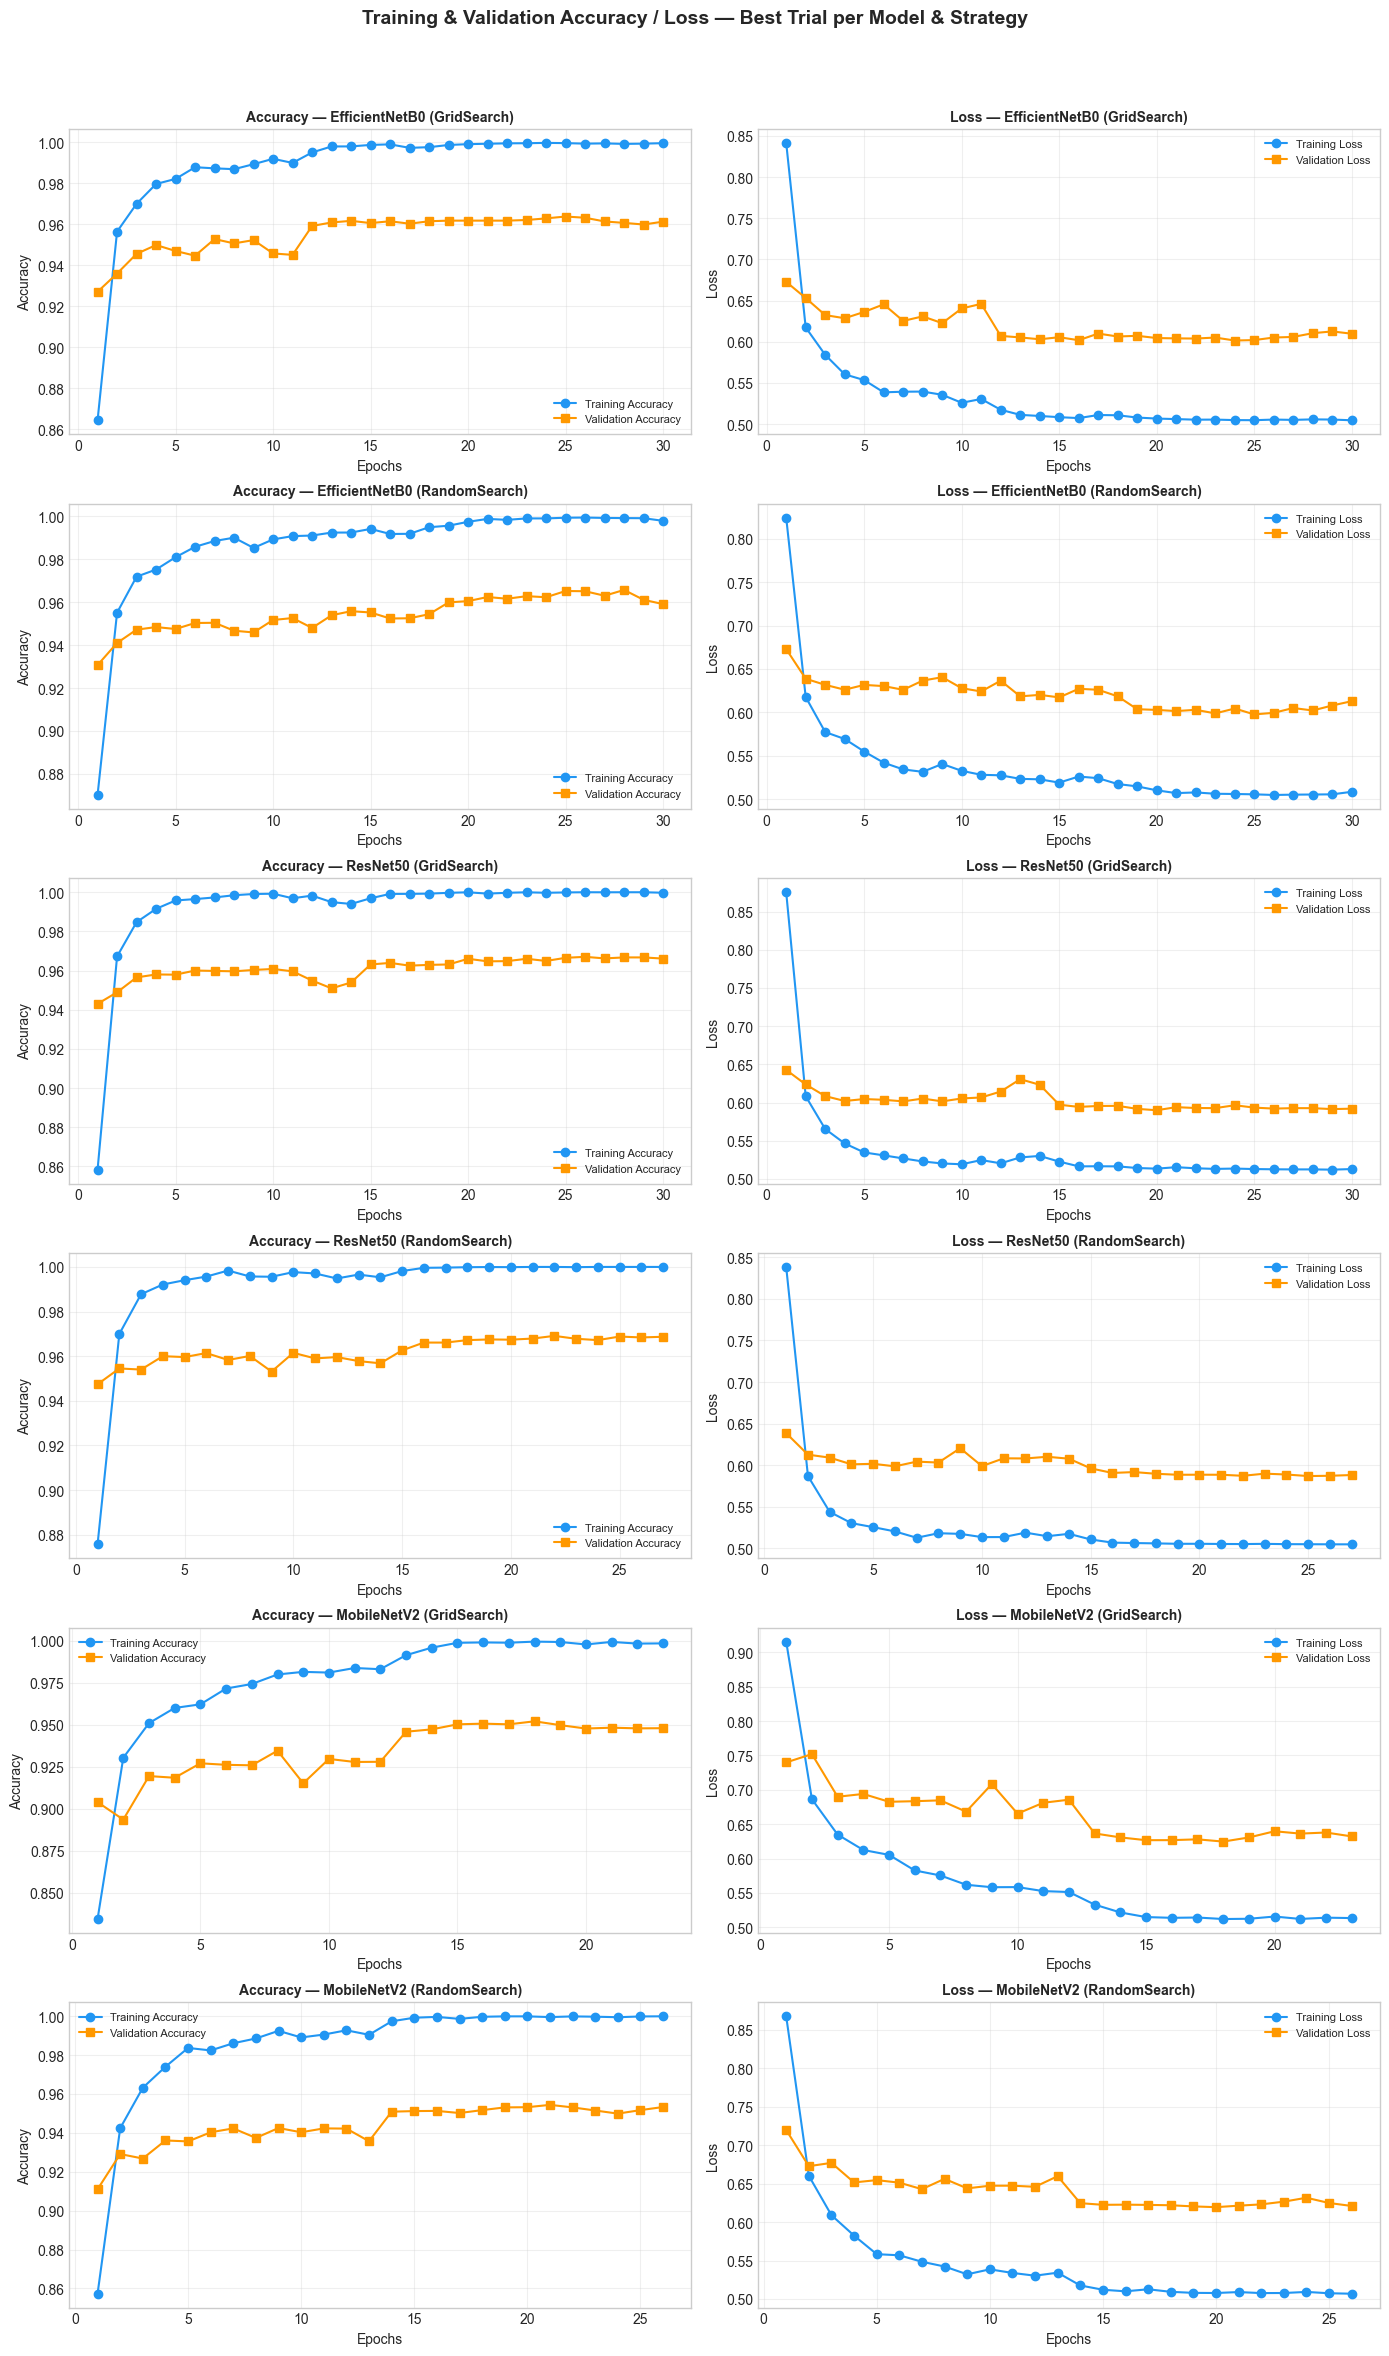

Training curves saved.


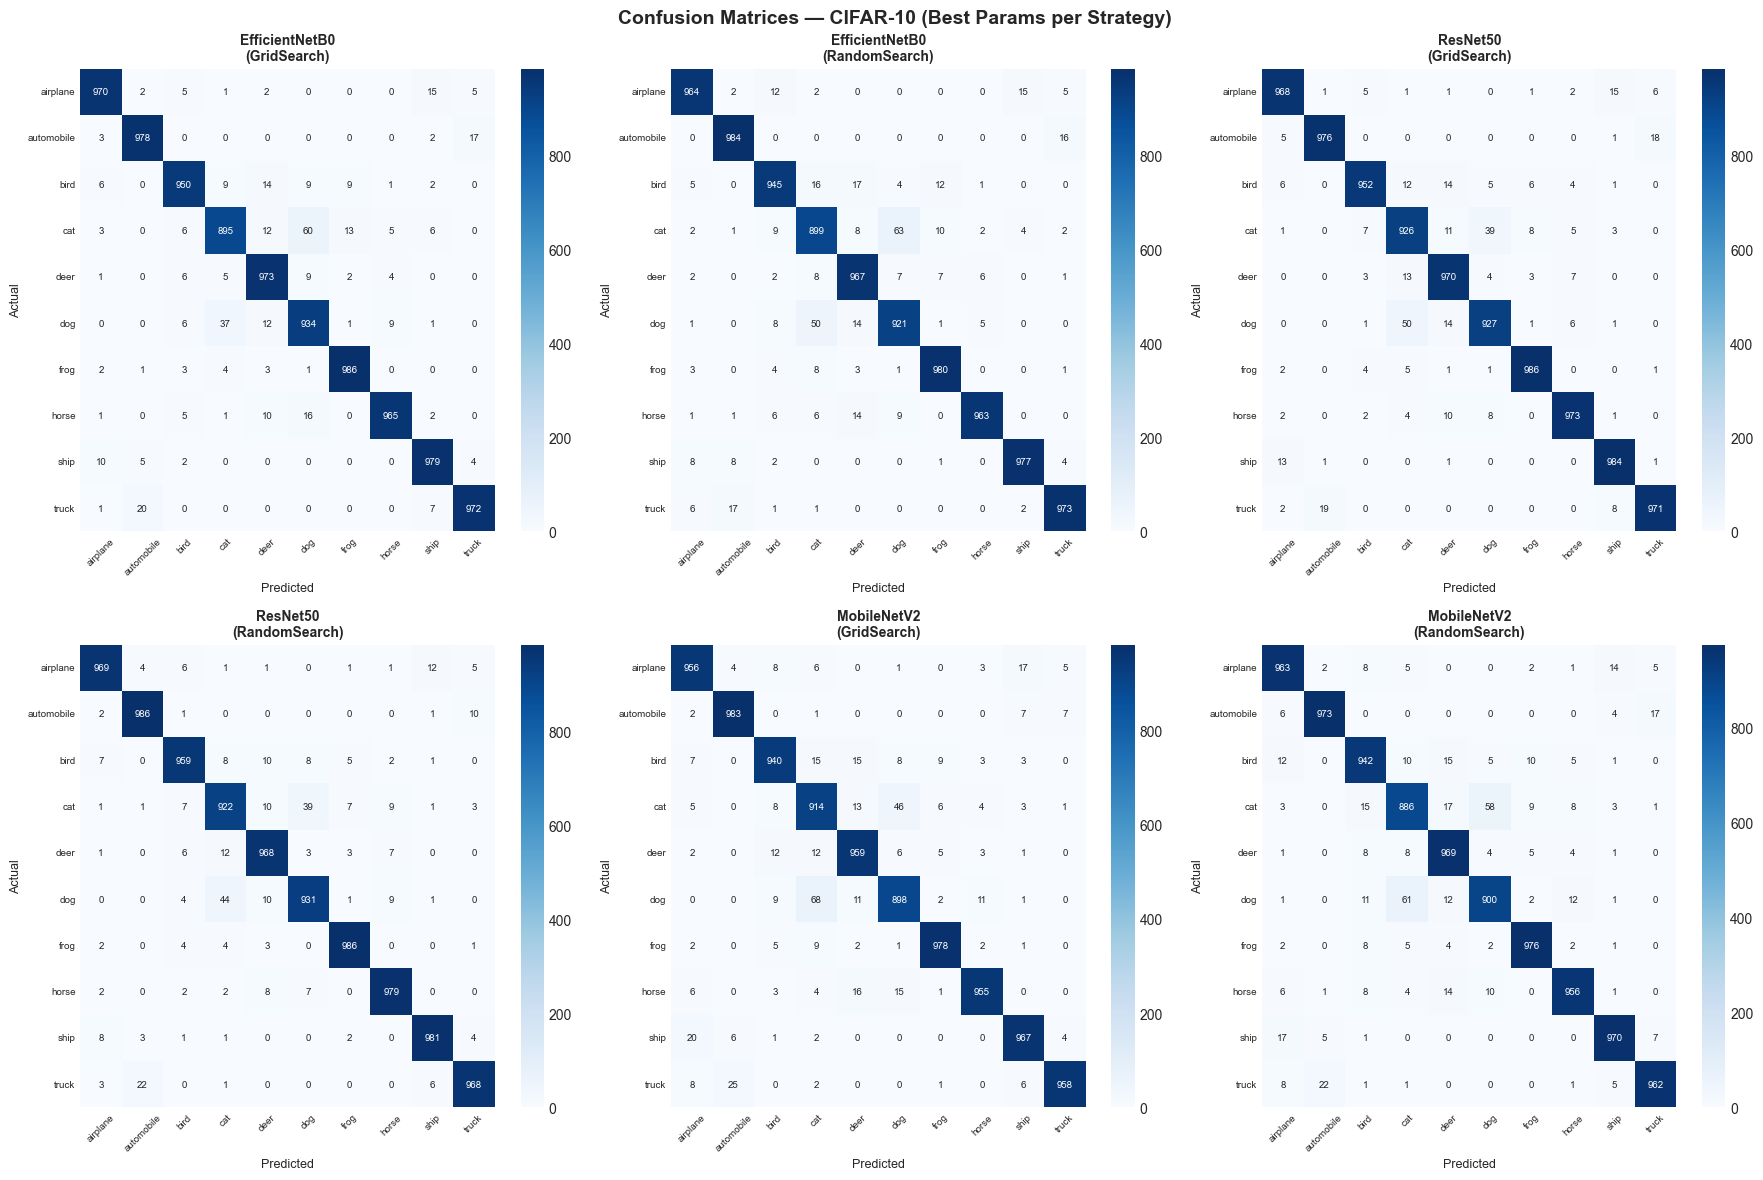

Confusion matrices saved.


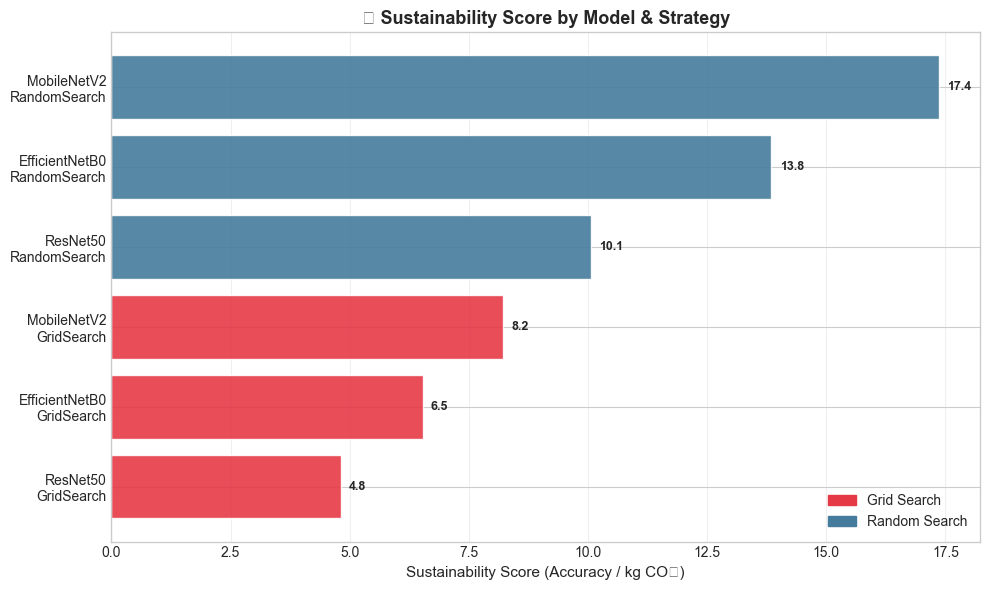

Sustainability score chart saved.


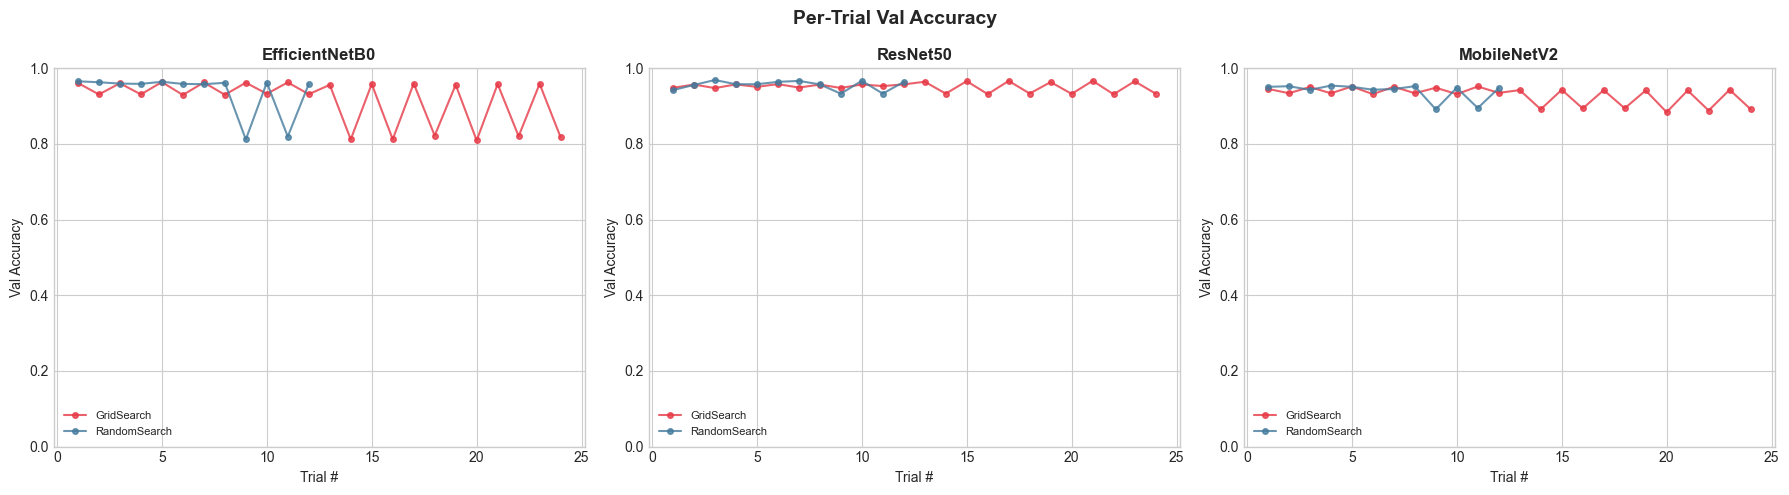

In [ ]:
# ── 10. VISUALIZATIONS ──────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"GridSearch": "#E63946", "RandomSearch": "#457B9D"}
x     = np.arange(len(MODELS_LIST))
width = 0.35

def extract_vals(df, method, col):
    return [df[(df["Method"]==method) & (df["Model"]==m)][col].values[0]
            for m in MODELS_LIST]

# ════ FIGURE 1: Accuracy / Time / CO2 / Scatter ════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Grid Search vs Random Search — CIFAR-10", fontsize=16, fontweight="bold")
ax = axes[0, 0]
for i, method in enumerate(["GridSearch", "RandomSearch"]):
    vals = extract_vals(df_summary, method, "Test Acc")
    bars = ax.bar(x + i*width - width/2, vals, width, label=method,
                  color=COLORS[method], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Test Accuracy", fontweight="bold"); ax.set_xticks(x)
ax.set_xticklabels(MODELS_LIST, rotation=10); ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1); ax.legend()
ax = axes[0, 1]
for i, method in enumerate(["GridSearch", "RandomSearch"]):
    vals = extract_vals(df_summary, method, "Total Time (min)")
    bars = ax.bar(x + i*width - width/2, vals, width, label=method,
                  color=COLORS[method], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"{v:.1f}m", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Total Search Time (minutes)", fontweight="bold"); ax.set_xticks(x)
ax.set_xticklabels(MODELS_LIST, rotation=10); ax.set_ylabel("Minutes"); ax.legend()
ax = axes[1, 0]
for i, method in enumerate(["GridSearch", "RandomSearch"]):
    vals = extract_vals(df_summary, method, "CO2 - Total All Trials (g)")
    bars = ax.bar(x + i*width - width/2, vals, width, label=method,
                  color=COLORS[method], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_title("CO₂ Emissions – Total (g)", fontweight="bold"); ax.set_xticks(x)
ax.set_xticklabels(MODELS_LIST, rotation=10); ax.set_ylabel("g CO₂eq"); ax.legend()
ax = axes[1, 1]
markers = {"EfficientNetB0": "o", "ResNet50": "s", "MobileNetV2": "^"}
for _, row in df_summary.iterrows():
    ax.scatter(row["CO2 - Total All Trials (g)"], row["Test Acc"],
               color=COLORS[row["Method"]], marker=markers[row["Model"]],
               s=150, edgecolors="black", linewidth=0.8, zorder=5)
    ax.annotate(f"{row['Model'][:6]}\n{row['Method'][:4]}",
                (row["CO2 - Total All Trials (g)"], row["Test Acc"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("CO₂ Emissions (g)"); ax.set_ylabel("Test Accuracy")
ax.set_title("Accuracy vs Emissions Trade-off", fontweight="bold")
legend_elements = [
    mpatches.Patch(color=COLORS["GridSearch"],   label="Grid Search"),
    mpatches.Patch(color=COLORS["RandomSearch"], label="Random Search"),
    plt.Line2D([0],[0],marker="o",color="w",markerfacecolor="gray",markersize=8,label="EfficientNetB0"),
    plt.Line2D([0],[0],marker="s",color="w",markerfacecolor="gray",markersize=8,label="ResNet50"),
    plt.Line2D([0],[0],marker="^",color="w",markerfacecolor="gray",markersize=8,label="MobileNetV2"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "results_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# ════ FIGURE 2: F1 / Precision / Recall / ROC-AUC ════
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Classification Metrics — Grid Search vs Random Search (CIFAR-10)",
              fontsize=15, fontweight="bold")
for col, title, ax in [
    ("F1",        "F1 Score (weighted)",  axes2[0, 0]),
    ("Precision", "Precision (weighted)", axes2[0, 1]),
    ("Recall",    "Recall (weighted)",    axes2[1, 0]),
    ("ROC-AUC",   "ROC-AUC (macro OvR)", axes2[1, 1]),
]:
    for i, method in enumerate(["GridSearch", "RandomSearch"]):
        vals = extract_vals(df_summary, method, col)
        bars = ax.bar(x + i*width - width/2, vals, width, label=method,
                      color=COLORS[method], alpha=0.85, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                    f"{v:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(title, fontweight="bold"); ax.set_xticks(x)
    ax.set_xticklabels(MODELS_LIST, rotation=10)
    ax.set_ylabel(col); ax.set_ylim(0, 1.12); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "metrics_f1_roc_precision_recall.png"), dpi=150, bbox_inches="tight")
plt.show()

# ════ FIGURE 3: Training & Validation Accuracy + Loss Curves ════
n_combos = len(all_results)
fig3, axes3 = plt.subplots(n_combos, 2, figsize=(14, 4 * n_combos))
fig3.suptitle("Training & Validation Accuracy / Loss — Best Trial per Model & Strategy",
              fontsize=14, fontweight="bold")

for row_idx, res in enumerate(all_results):
    hist  = res.get("best_trial_history", {})
    label = f"{res['model']} ({res['method']})"
    erange = range(1, len(hist.get("train_acc", [])) + 1)
    ax_acc  = axes3[row_idx, 0]
    ax_loss = axes3[row_idx, 1]
    if hist:
        ax_acc.plot(erange, hist["train_acc"], "o-", color="#2196F3", label="Training Accuracy")
        ax_acc.plot(erange, hist["val_acc"],   "s-", color="#FF9800", label="Validation Accuracy")
        ax_loss.plot(erange, hist["train_loss"], "o-", color="#2196F3", label="Training Loss")
        ax_loss.plot(erange, hist["val_loss"],   "s-", color="#FF9800", label="Validation Loss")
    ax_acc.set_title(f"Accuracy — {label}", fontsize=10, fontweight="bold")
    ax_acc.set_xlabel("Epochs"); ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(fontsize=8); ax_acc.grid(True, alpha=0.3)
    ax_loss.set_title(f"Loss — {label}", fontsize=10, fontweight="bold")
    ax_loss.set_xlabel("Epochs"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved.")

# ════ FIGURE 4: Confusion Matrices ════
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 12))
fig4.suptitle("Confusion Matrices — CIFAR-10 (Best Params per Strategy)",
              fontsize=14, fontweight="bold")
axes4_flat = axes4.flatten()
for idx, tr in enumerate(test_results):
    ax = axes4_flat[idx]
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(tr["labels"], tr["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 7})
    ax.set_title(f"{tr['model']}\n({tr['method']})",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=9); ax.set_ylabel("Actual", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)
for idx in range(len(test_results), len(axes4_flat)):
    axes4_flat[idx].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved.")

# ════ FIGURE 5: Sustainability Score ════
sustain_rows = []
for res, tr in zip(all_results, test_results):
    total_kg_co2 = res["total_emissions_g"] / 1000.0
    score = tr["test_acc"] / total_kg_co2 if total_kg_co2 > 0 else 0
    sustain_rows.append({
        "label":  f"{res['model']}\n{res['method']}",
        "score":  score,
        "method": res["method"],
    })
sustain_rows.sort(key=lambda r: r["score"])
fig5, ax5 = plt.subplots(figsize=(10, 6))
bar_colors = [COLORS[r["method"]] for r in sustain_rows]
bars = ax5.barh([r["label"] for r in sustain_rows],
                [r["score"] for r in sustain_rows],
                color=bar_colors, edgecolor="white", alpha=0.9)
max_score = max(r["score"] for r in sustain_rows)
for bar, row in zip(bars, sustain_rows):
    ax5.text(bar.get_width() + max_score * 0.01, bar.get_y() + bar.get_height()/2,
             f"{row['score']:.1f}", va="center", fontsize=9, fontweight="bold")
ax5.set_xlabel("Sustainability Score (Accuracy / kg CO₂)", fontsize=11)
ax5.set_title("🌿 Sustainability Score by Model & Strategy", fontsize=13, fontweight="bold")
legend_patches = [
    mpatches.Patch(color=COLORS["GridSearch"],   label="Grid Search"),
    mpatches.Patch(color=COLORS["RandomSearch"], label="Random Search"),
]
ax5.legend(handles=legend_patches, loc="lower right")
ax5.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sustainability_score.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Sustainability score chart saved.")

# ════ Per-trial val accuracy curves ════
fig6, axes6 = plt.subplots(1, 3, figsize=(18, 5))
fig6.suptitle("Per-Trial Val Accuracy", fontsize=14, fontweight="bold")
for ax, model_name in zip(axes6, MODELS_LIST):
    for method, color in COLORS.items():
        res  = next(r for r in all_results
                    if r["model"]==model_name and r["method"]==method)
        accs = [t["val_accuracy"] for t in res["all_trials"]]
        ax.plot(range(1, len(accs)+1), accs, marker="o", markersize=4,
                label=method, color=color, alpha=0.8)
    ax.set_title(model_name, fontweight="bold")
    ax.set_xlabel("Trial #"); ax.set_ylabel("Val Accuracy")
    ax.legend(fontsize=8); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "trial_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── 11. TERMINAL-FRIENDLY RESULTS SUMMARY ─────────────────────────────────────
COLORS_TEXT = {'GridSearch': '\033[91m', 'RandomSearch': '\033[94m'}
RESET = '\033[0m'; BOLD = '\033[1m'

for res in all_results:
    color = COLORS_TEXT.get(res['method'], '')
    print(f"\n{BOLD}{color}{'='*60}")
    print(f"  {res['method']} | {res['model']}")
    print(f"{'='*60}{RESET}")
    print(f"  Best val acc  : {res['best_val_acc']:.4f}  (Trial #{res['best_trial']} of {res['n_trials']})")
    print(f"  Best params   : {res['best_params']}")
    print(f"  Total time    : {res['total_time_s']/60:.1f} min")
    print(f"  CO₂ total     : {res['total_emissions_g']:.3f} g")
    print(f"  CO₂ to best   : {res['to_best_emissions_g']:.3f} g")
    print(f"\n  {'Trial':<6} {'Val Acc':>8} {'Epochs':>7} {'Time(s)':>9} {'CO₂(g)':>9}  Params")
    print(f"  {'-'*75}")
    for i, t in enumerate(res['all_trials']):
        marker = '  ◀ BEST' if (i+1) == res['best_trial'] else ''
        p = t['params']
        pstr = f"lr={p['learning_rate']}  drop={p['dropout_rate']}  units={p['dense_units']}  opt={p['optimizer']}"
        print(f"  {i+1:<6} {t['val_accuracy']:>8.4f} {t['epochs_trained']:>7} "
              f"{t['duration']:>9.1f} {t['trial_emissions_g']:>9.4f}  {pstr}{marker}")

# Efficiency comparison (normalised for different trial counts)
print(f"\n{BOLD}{'='*80}")
print('EFFICIENCY: Random vs Grid  (Random uses fewer trials — normalised comparison)')
print(f"{'='*80}{RESET}")
for model_name in MODELS_LIST:
    g = df_summary[(df_summary['Method']=='GridSearch')   & (df_summary['Model']==model_name)].iloc[0]
    r = df_summary[(df_summary['Method']=='RandomSearch') & (df_summary['Model']==model_name)].iloc[0]
    acc_diff  = r['Test Acc'] - g['Test Acc']
    time_diff = r['Total Time (min)'] - g['Total Time (min)']
    co2_diff  = r['CO2 - To Best Trial (g)'] - g['CO2 - To Best Trial (g)']
    # Cost-normalised: accuracy per minute
    g_eff = g['Test Acc'] / g['Total Time (min)'] if g['Total Time (min)'] > 0 else 0
    r_eff = r['Test Acc'] / r['Total Time (min)'] if r['Total Time (min)'] > 0 else 0
    print(f"\n  {model_name}")
    print(f"    Trials        : Grid={int(g['N Trials'])}  Random={int(r['N Trials'])}")
    print(f"    Acc       Δ  : {acc_diff:+.4f}  {'✅ Random better' if acc_diff > 0.001 else ('✅ Grid better' if acc_diff < -0.001 else '🟰 Tie')}")
    print(f"    Time      Δ  : {time_diff:+.1f} min  {'✅ Random faster' if time_diff < 0 else '✅ Grid faster'}")
    print(f"    CO₂       Δ  : {co2_diff:+.4f} g  {'✅ Random greener' if co2_diff < 0 else '✅ Grid greener'}")
    print(f"    Acc/min (eff) : Grid={g_eff:.5f}  Random={r_eff:.5f}  {'✅ Random more efficient' if r_eff > g_eff else '✅ Grid more efficient'}")


  GridSearch | EfficientNetB0
  Best val acc  : 0.9637  (Trial #5 of 24)
  Best params   : {'learning_rate': 0.001, 'dropout_rate': 0.2, 'dense_units': 256, 'optimizer': 'adam'}
  Total time    : 65.9 min
  CO₂ total     : 147.043 g
  CO₂ to best   : 29.064 g

  Trial   Val Acc  Epochs   Time(s)    CO₂(g)  Params
  ---------------------------------------------------------------------------
  1        0.9613      24     144.0    5.3659  lr=0.001  drop=0.2  units=64  opt=adam
  2        0.9310      30     176.4    6.5730  lr=0.001  drop=0.2  units=64  opt=sgd
  3        0.9605      18     106.9    3.9858  lr=0.001  drop=0.2  units=128  opt=adam
  4        0.9311      30     175.5    6.5408  lr=0.001  drop=0.2  units=128  opt=sgd
  5        0.9637      30     177.1    6.5984  lr=0.001  drop=0.2  units=256  opt=adam  ◀ BEST
  6        0.9296      30     175.9    6.5539  lr=0.001  drop=0.2  units=256  opt=sgd
  7        0.9627      23     135.8    5.0618  lr=0.001  drop=0.4  units=64  opt=

In [ ]:
# ── 12. SAVE RESULTS ──────────────────────────────────────────────────────────
def make_serializable(obj):
    if isinstance(obj, dict):  return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [make_serializable(i) for i in obj]
    if isinstance(obj, (np.integer, np.floating)): return float(obj)
    return obj

csv_path  = os.path.join(OUTPUT_DIR, 'summary_results.csv')
json_path = os.path.join(OUTPUT_DIR, 'full_results.json')

df_summary.to_csv(csv_path, index=False)
with open(json_path, 'w') as f:
    json.dump(make_serializable(all_results), f, indent=2)

print('Results saved:')
print(f'  {csv_path}')
print(f'  {json_path}')
print(f'  {OUTPUT_DIR}/results_comparison.png')
print(f'  {OUTPUT_DIR}/trial_curves.png')

Results saved:
  ./cifar10_output\summary_results.csv
  ./cifar10_output\full_results.json
  ./cifar10_output/results_comparison.png
  ./cifar10_output/trial_curves.png
